# Overview

## Create the simulations

In [ ]:
import numpy as np
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.plt import (
    plot_colormap, plot_line, create_multifigure, save_figure,
    get_ipynb_file_name, set_ipynb_variable, plot_colormap_multifigure,
)
from lucifex.utils.npy_utils import as_index
from crocodil.theory.grid_resolution import threshold_rayleigh
from crocodil.dns.system_aMu import (
    dns_system_aMu, SYSTEM_A_MU_REFERENCE,
)

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
ANIM = set_ipynb_variable('ANIM', False)

gamma_opts = (1.0, -1.0)
simulations: dict[float, Simulation] = {}

for gamma in gamma_opts:
    simulations[gamma] = dns_system_aMu(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **SYSTEM_A_MU_REFERENCE.replace(gamma=gamma),
        viscosity_type='exponential',
        dt_max=0.1,
        dt_Cu=0.5,
        dt_Cd=0.75,
        dt_Cr=0.1,
        c_stabilization=None,
        c_limits=True,
        diagnostic=True,
    )
    
Ra, gamma, Lx, Ly = (
    float(i) for i in simulations[True]['Ra', 'gamma', 'Lx', 'Ly']
)
Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {Ra} , Ra_thresh = {Ra_thresh}")

Ra = 1000.0 , Ra_thresh = 1800.0


## Run the simulations

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 200)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for gamma, sim in simulations.items():
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: 
        xdmf_to_npz(sim, delete_xdmf=False)
    else:
        write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')

  0%|          | 0/200 [00:00<?, ?it/s]

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_42ffadf8a3fc0ae9b60f919bdf4e5355bb73fa02' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_42ffadf8a3fc0ae9b60f919bdf4e5355bb73fa02.c -o ./libffcx_forms_42ffadf8a3fc0ae9b60f919bdf4e5355bb73fa02.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_42ffadf8a3fc0ae9b60f919bdf4e5355bb73fa02.o -o ./libffcx_forms_42ffadf8a3fc0ae9b60f919bdf4e5355bb73fa02.cpython-310-darwin.

  0%|          | 0/200 [00:00<?, ?it/s]

## Physical diagnostics

### Mass

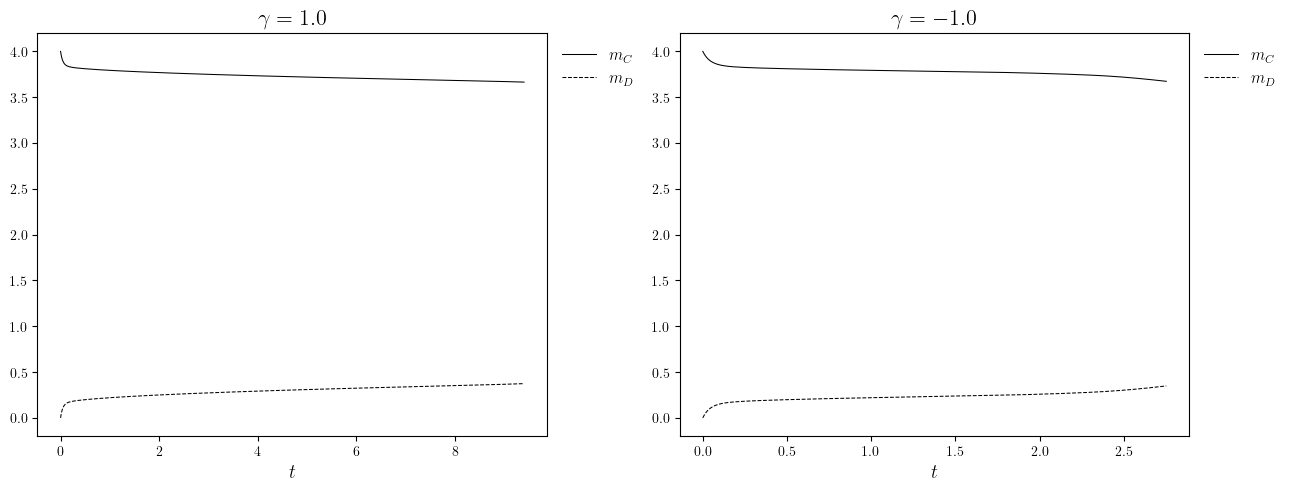

In [ ]:
mfig, axs, _ = create_multifigure(n_cols=2)

for i, (gamma, sim) in enumerate(simulations.items()):
    mC, mD = sim['mC', 'mD']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    plot_line(
        mfig, axs[i],
        [
            (mC.time_series, mC.value_series), 
            (mD.time_series, mD.value_series),
        ],
        cyc='black',
        x_label='$t$',
        title=f'$\gamma={gamma}$',
        legend_labels=[
            '$m_C$', 
            '$m_D$', 
        ],
    )

### Flux

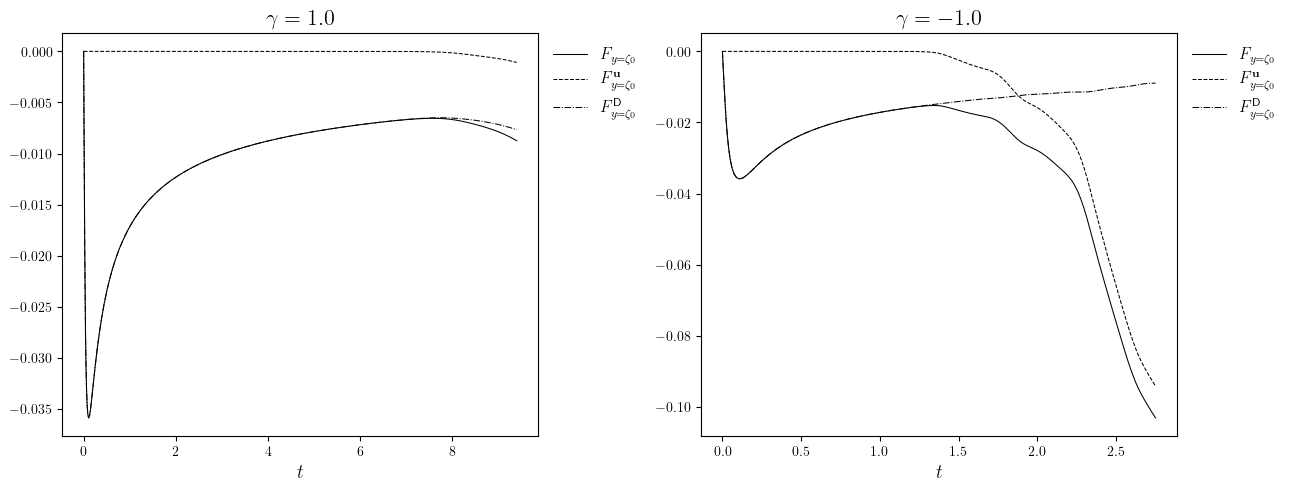

In [ ]:
mfig, axs, _ = create_multifigure(n_cols=2)

for i, (gamma, sim) in enumerate(simulations.items()):
    f = sim['f']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    plot_line(
        mfig, axs[i],
        [
            (fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), 
            (fZeta0.time_series, fZeta0.value_series)
        ],
        cyc='black',
        x_label='$t$',
        title=f'$\gamma={gamma}$',
        legend_labels=[
            '$F_{y=\zeta_0}$', 
            '$F_{y=\zeta_0}^{\mathbf{u}}$', 
            '$F_{y=\zeta_0}^{\mathsf{D}}$',
        ],
    )

## Visualization

### Concentration and saturation

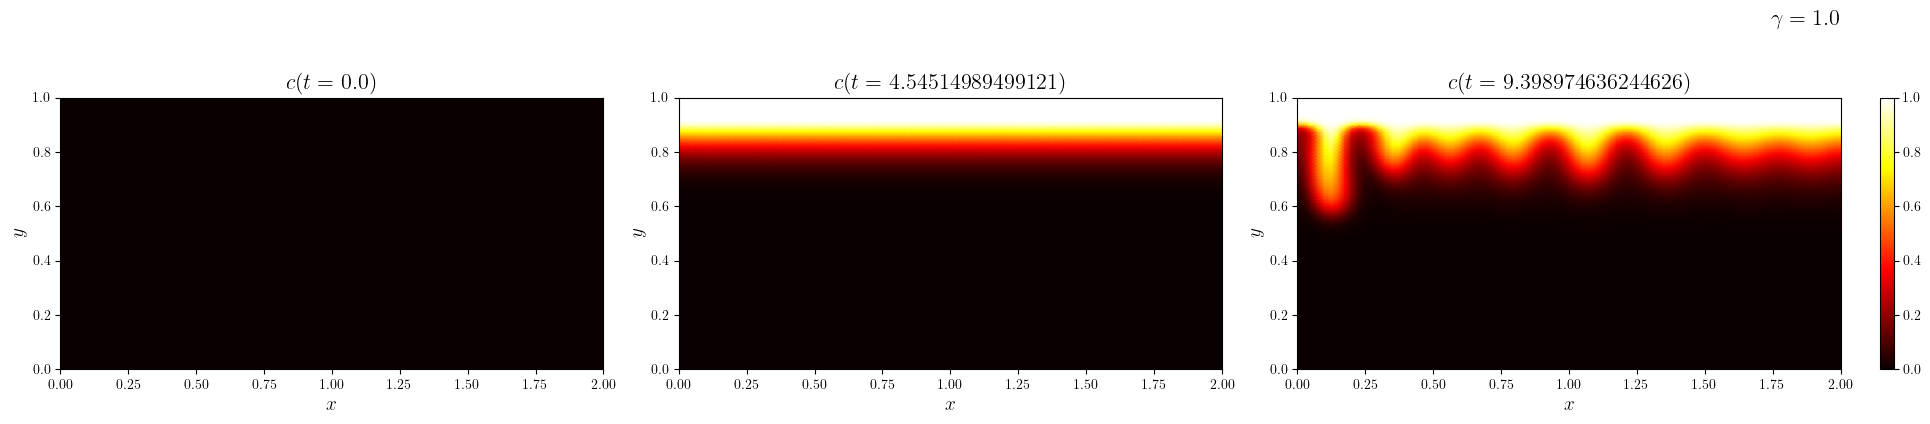

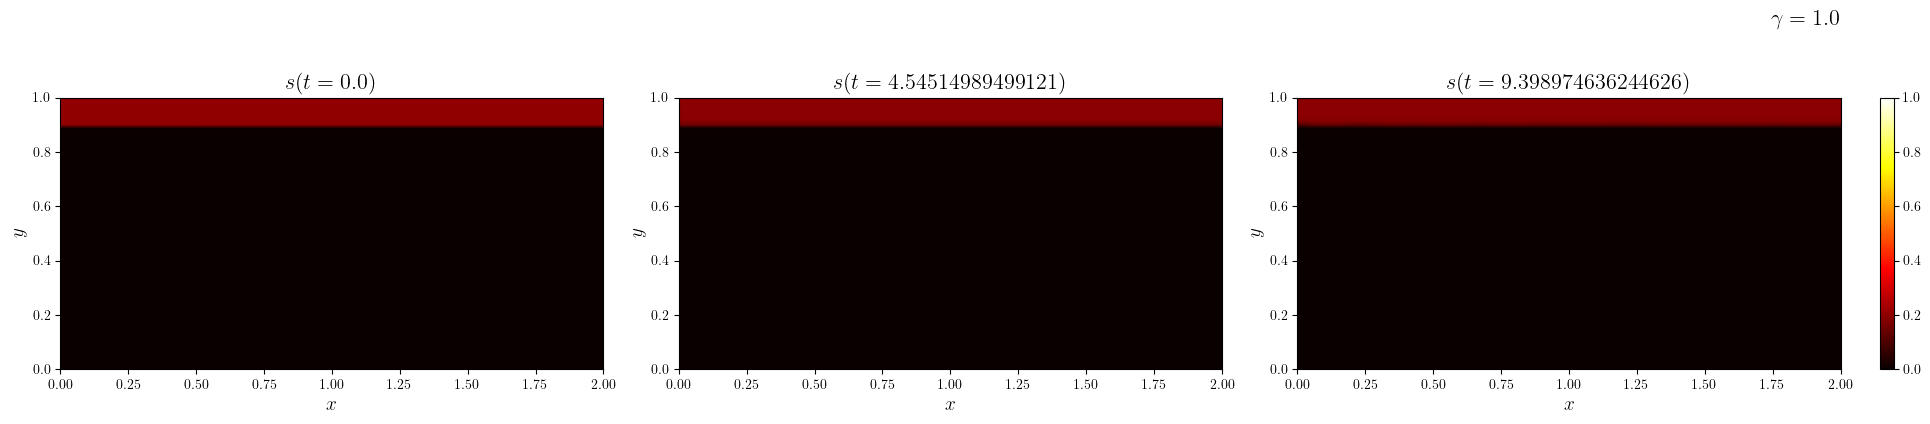

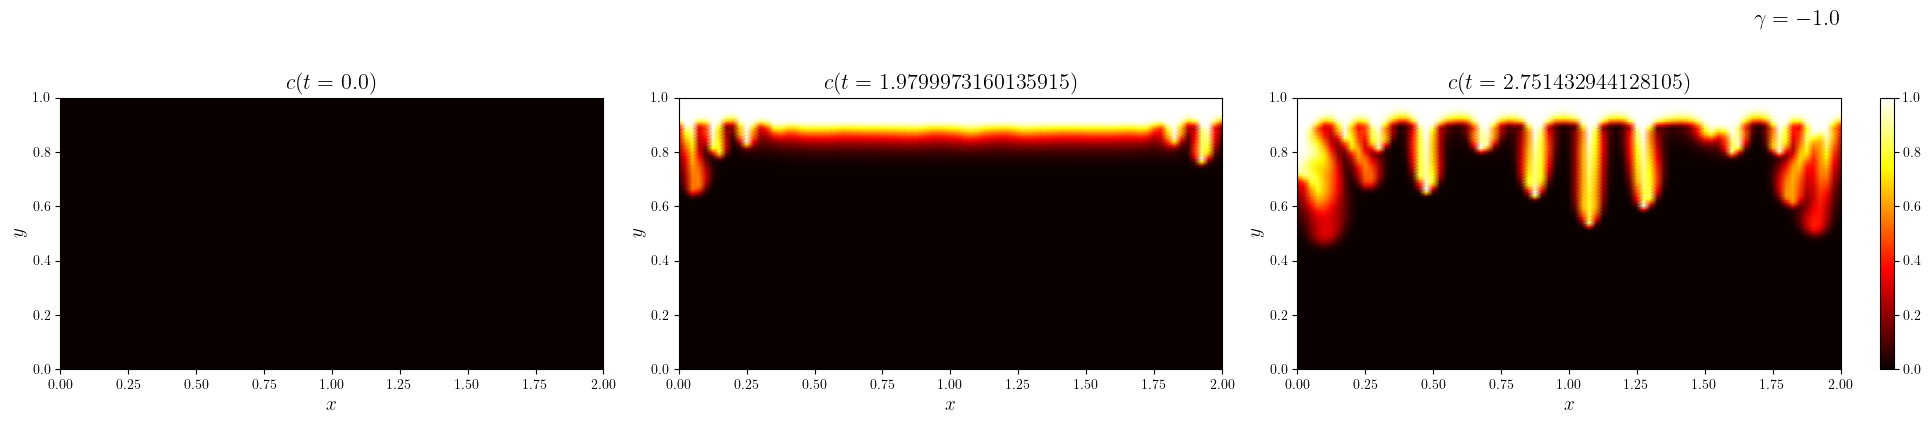

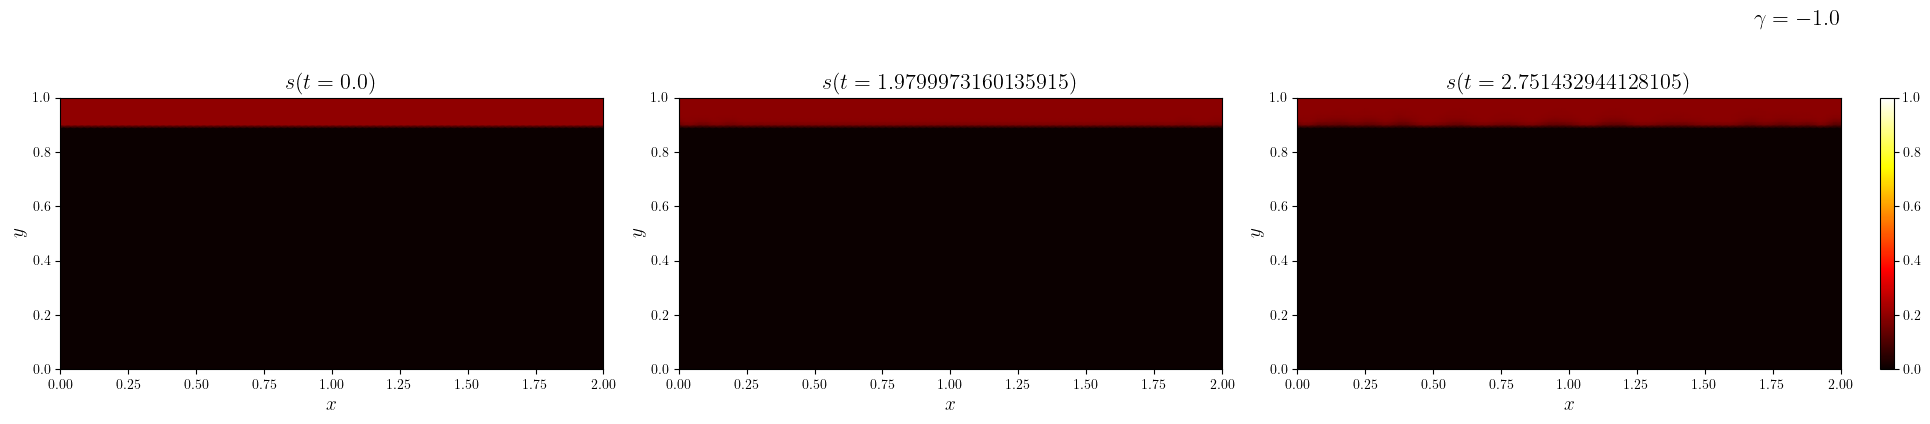

In [ ]:
index_targets = (0, 0.5, -1)
tex_names = ('c', 's')

for gamma, sim in simulations.items():
    c, s = sim['c', 's']
    time_indices = as_index(c.time_series, index_targets, fraction=True)
    for w, n in zip((c, s), tex_names):
        mfig, axs, _ = plot_colormap_multifigure(
            n_cols=len(time_indices), 
            cbars=(0, 1), 
            suptitle=f'$\gamma={gamma}$',
        )(
            [w.series[i] for i in time_indices],
            title=[f'${n}(t={w.time_series[i]})$' for i in time_indices],
        )

### Thumbnail image

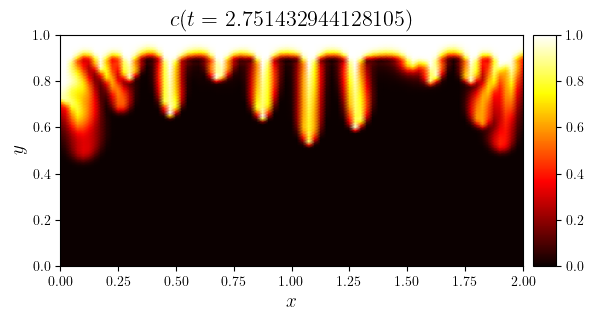

In [ ]:
time_index = -1
c = simulations[gamma_opts[-1]]['c']
fig, ax = plot_colormap(
    c.series[time_index], 
    title=f'$c(t={c.time_series[time_index]})$',
)
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')